In [1]:
import numpy as np
import pandas as pd

# 1. 원본 데이터 로드
print("1. 데이터 불러오는 중...")
df_atmos = pd.read_csv("train_atmos.csv")
df_wave = pd.read_csv("train_wave.csv")

# 2. 시간 컬럼 포맷 변환
df_atmos["time"] = pd.to_datetime(df_atmos["time"])
df_wave["time"] = pd.to_datetime(df_wave["time"])

# 3. Outer Join으로 전체 시간대 병합 (보간 없이 결측치 유지)
print("2. 데이터 병합 중...")
df_merged = pd.merge(df_atmos, df_wave, on=["station", "time"], how="outer")

# 4. 정점 및 시간 기준 정렬
df_merged = df_merged.sort_values(by=["station", "time"]).reset_index(
    drop=True
)

# 5. 지정된 순서대로 컬럼 재배치 (데이터에 존재하는 컬럼만 우선 정렬)
desired_order = [
    "case_id",
    "station",
    "step_minute",
    "time",
    "hs",
    "tp",
    "hmax",
    "wvdir",
    "wspd",
    "gust",
    "wdir",
    "airt",
    "relh",
    "caph",
]
existing_cols = [c for c in desired_order if c in df_merged.columns]
remaining_cols = [c for c in df_merged.columns if c not in existing_cols]
df_merged = df_merged[existing_cols + remaining_cols]

# 6. 파일 저장
output_path = "train_merged.csv"
df_merged.to_csv(output_path, index=False)
print(f"3. 저장 완료: {output_path} (총 {len(df_merged):,}개 행)")

# 7. 컬럼 순서 및 결측치 현황 출력
print("\n--- 정렬된 컬럼 목록 ---")
print(list(df_merged.columns))
print("\n--- 컬럼별 결측치(NaN) 개수 ---")
print(df_merged.isna().sum())
print("\n--- 데이터 샘플 (상위 5행) ---")
print(df_merged.head())

1. 데이터 불러오는 중...
2. 데이터 병합 중...
3. 저장 완료: train_merged.csv (총 183,600개 행)

--- 정렬된 컬럼 목록 ---
['station', 'time', 'hs', 'tp', 'hmax', 'wvdir', 'wspd', 'gust', 'wdir', 'airt', 'relh', 'caph']

--- 컬럼별 결측치(NaN) 개수 ---
station        0
time           0
hs         75670
tp         77487
hmax       75478
wvdir      74754
wspd       55364
gust       55348
wdir       55311
airt       55468
relh       69920
caph       55024
dtype: int64

--- 데이터 샘플 (상위 5행) ---
  station                      time    hs    tp  hmax   wvdir   wspd   gust  \
0   G-ORS 2024-01-01 00:00:00+09:00  2.29  7.01  3.72  334.22  8.180   9.65   
1   G-ORS 2024-01-01 00:10:00+09:00   NaN   NaN   NaN     NaN  9.200  10.87   
2   G-ORS 2024-01-01 00:20:00+09:00  2.27  7.10  3.69  332.58  7.977  10.05   
3   G-ORS 2024-01-01 00:30:00+09:00   NaN   NaN   NaN     NaN  9.310  10.57   
4   G-ORS 2024-01-01 00:40:00+09:00  2.33  8.19  3.79  327.86  6.713   7.72   

    wdir   airt   relh      caph  
0  350.2  7.458  60.48  1023.736  

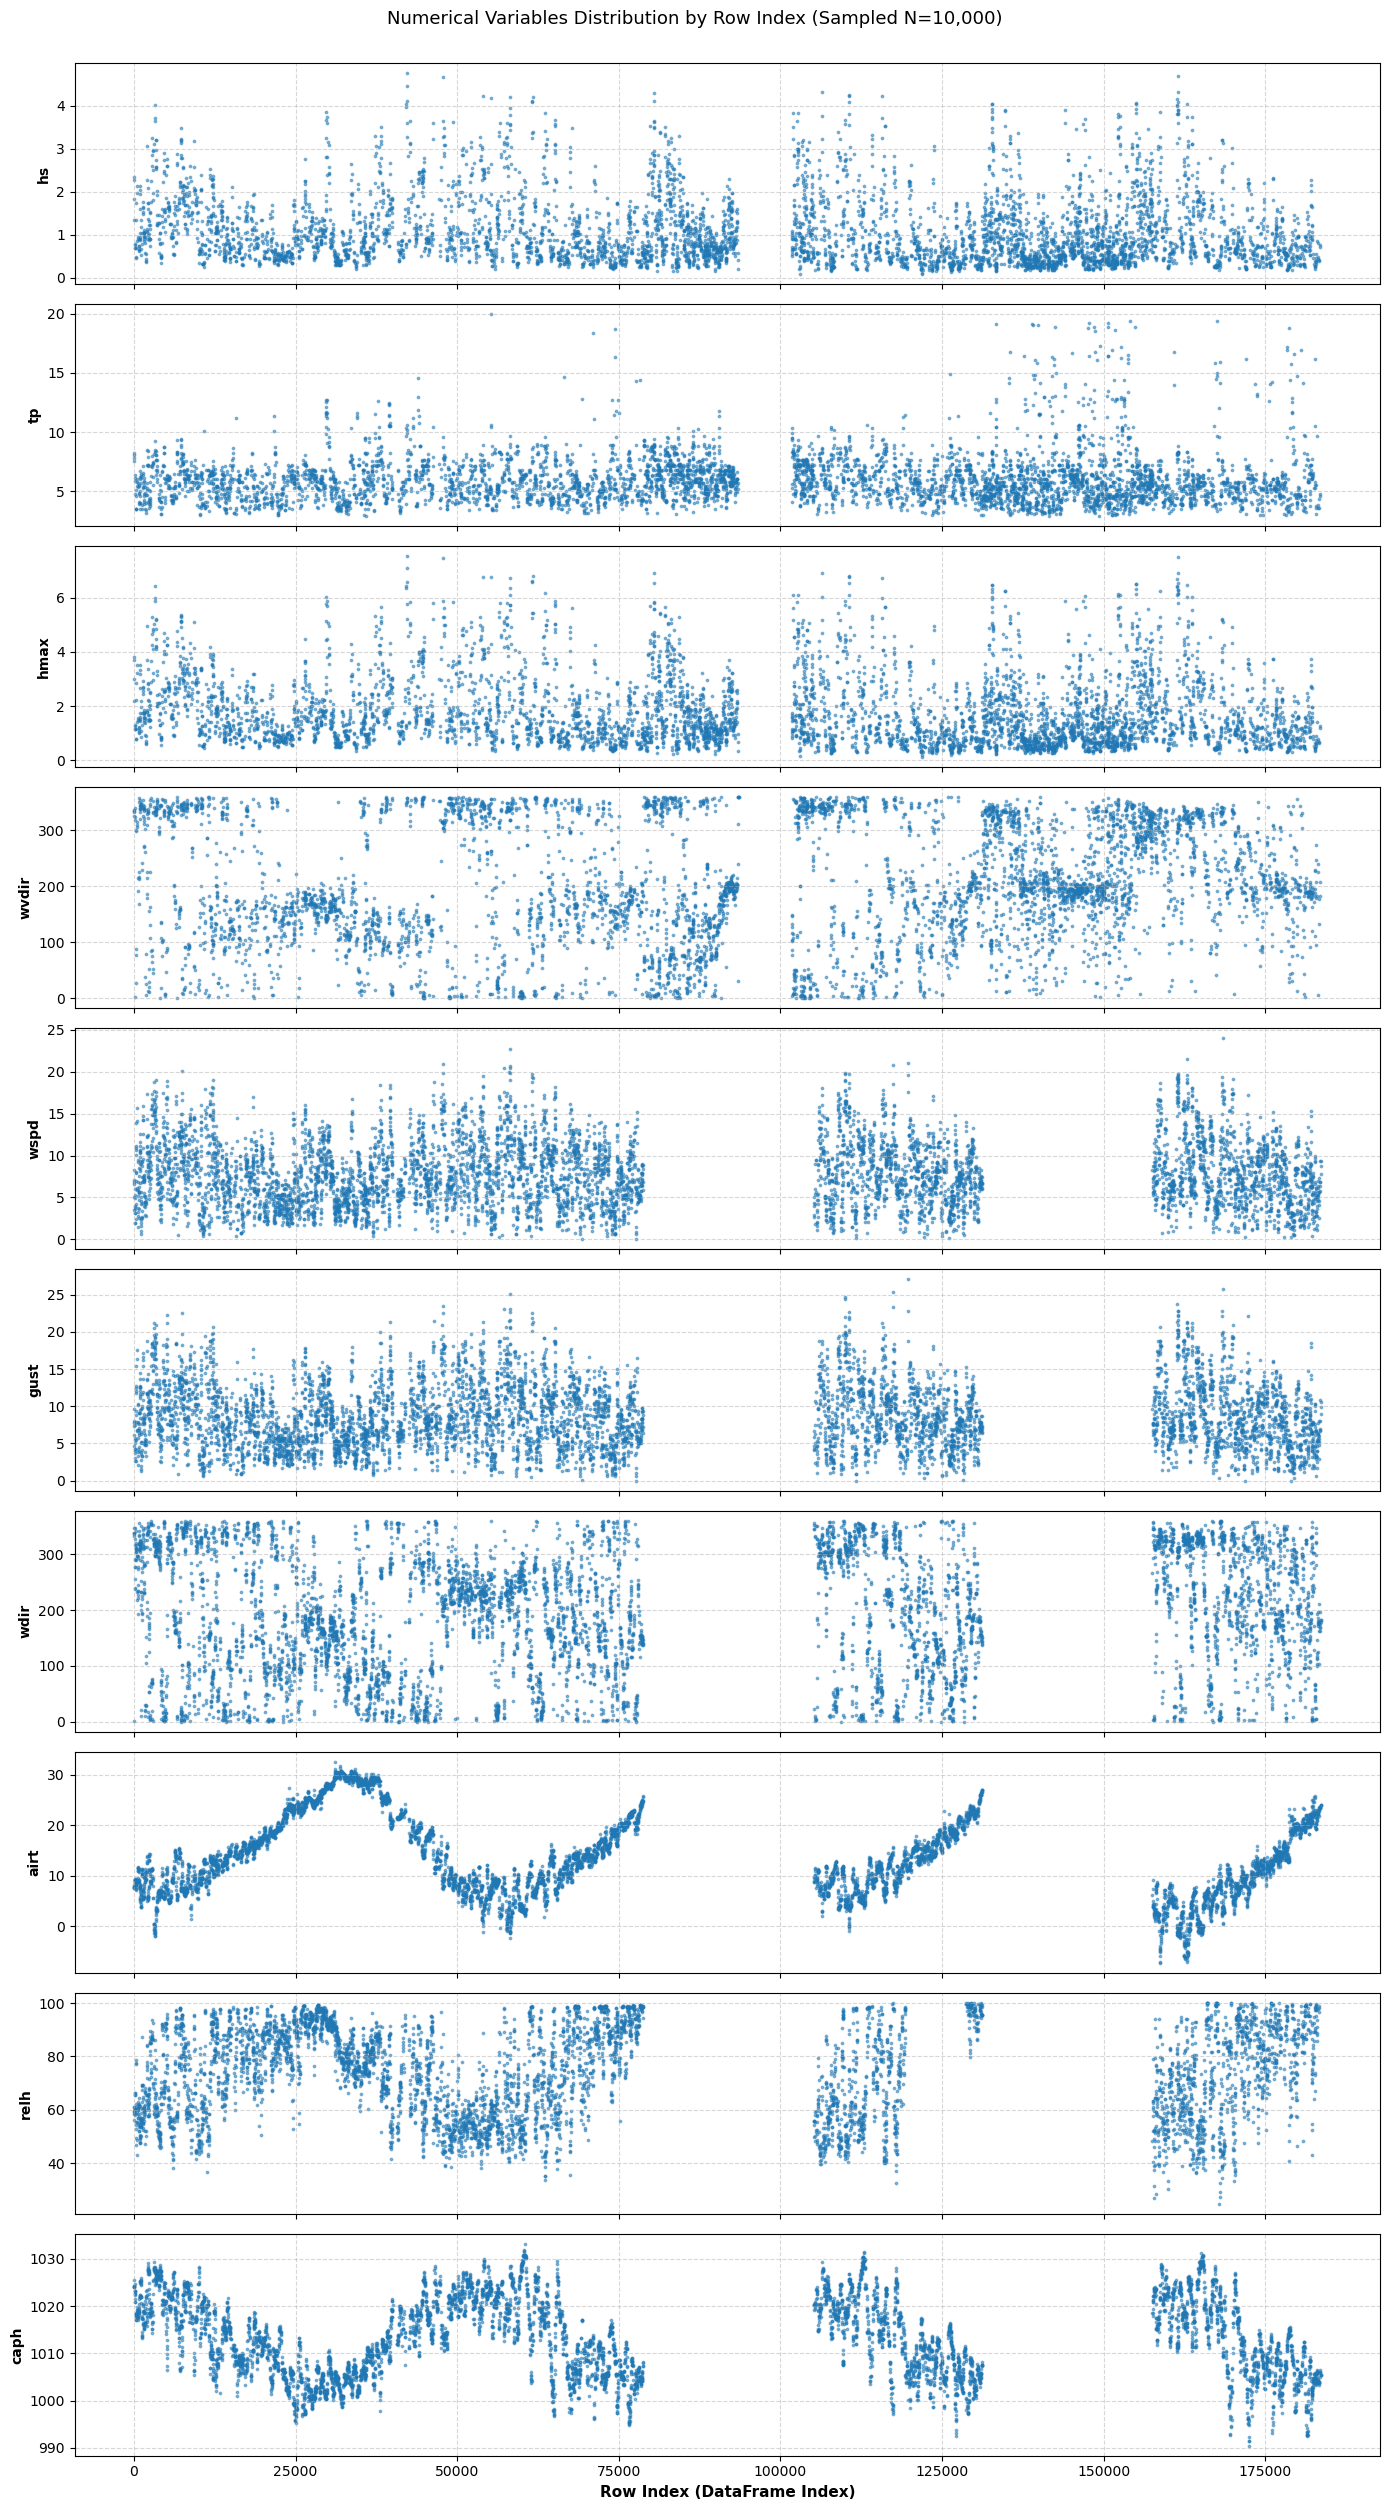

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. 병합 데이터 로드
df = pd.read_csv("train.csv")

# 2. 플롯 대상 수치형 컬럼 추출 (시간 및 범주형 제외)
exclude_cols = ["station", "time", "case_id"]
numeric_cols = [c for c in df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])]

# 3. 샘플링 (전체 행이 많을 경우 렌더링 속도를 위해 10,000개 샘플링)
sample_size = min(10000, len(df))
df_sample = df.sample(n=sample_size, random_state=42).sort_index()

# 4. 서브플롯 생성 (수치형 컬럼 수에 맞춰 행 구성)
n_cols = len(numeric_cols)
fig, axes = plt.subplots(nrows=n_cols, ncols=1, figsize=(14, 2.5 * n_cols), sharex=True)

if n_cols == 1:
    axes = [axes]

for ax, col in zip(axes, numeric_cols):
    ax.scatter(df_sample.index, df_sample[col], s=3, alpha=0.5, color='tab:blue')
    ax.set_ylabel(col, fontsize=10, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)

axes[-1].set_xlabel("Row Index (DataFrame Index)", fontsize=11, fontweight='bold')
plt.suptitle(f"Numerical Variables Distribution by Row Index (Sampled N={sample_size:,})", fontsize=13, y=1.002)
plt.tight_layout()
plt.show()

In [7]:
import numpy as np
import pandas as pd

df = pd.read_csv("train.csv")
df["time"] = pd.to_datetime(df["time"])

# --- 1. 문맥적 이상치 탐지 (Contextual) ---
# a. Obvious (센서 상하한)
df.loc[df["hs"] <= 0, "hs"] = np.nan
df.loc[df["wspd"] < 0, "wspd"] = np.nan
df.loc[(df["caph"] < 950) | (df["caph"] > 1050), "caph"] = np.nan
df.loc[(df["relh"] < 0) | (df["relh"] > 100), "relh"] = np.nan

# b. Repeated values (센서 고착: 6연속 동일값 탐지)
for col in ["hs", "wspd", "caph"]:
    is_frozen = (df[col].diff() == 0) & (df[col].shift(1).diff() == 0) & (df[col].shift(2).diff() == 0)
    df.loc[is_frozen, col] = np.nan

# d. Spikes (10분 간 급격한 스파이크: 차분 임계치 초과)
# 10분 만에 유의파고가 2.5m 이상 튀는 비물리적 급변 마스킹
df.loc[df.groupby("station")["hs"].diff().abs() > 2.5, "hs"] = np.nan


# --- 2. 상관관계 위반 이상치 탐지 (Relational) ---
# hmax < hs
df.loc[df["hmax"] < df["hs"], "hmax"] = np.nan

# gust < wspd
df.loc[df["gust"] < df["wspd"], "gust"] = np.nan


# --- 3. 정제 후 단기 결측치 보간 (최대 2칸) ---
numeric_cols = ["hs", "tp", "hmax", "wvdir", "wspd", "gust", "wdir", "airt", "relh", "caph"]
df[numeric_cols] = df.groupby("station")[numeric_cols].transform(
    lambda group: group.interpolate(method="linear", limit=2)
)

# 최종 물리적 바닥값 클리핑
df["hs"] = df["hs"].clip(lower=0.01)
df["wspd"] = df["wspd"].clip(lower=0.0)

df.to_csv("train_anomaly_cleaned.csv", index=False)
print("슬라이드 기반 문맥/상관관계 이상치 마스킹 및 단기 보간 완료!")

슬라이드 기반 문맥/상관관계 이상치 마스킹 및 단기 보간 완료!


In [8]:
import pandas as pd

# 1. 이상치 처리 완료 파일 로드
df = pd.read_csv("train_anomaly_cleaned.csv")
df["time"] = pd.to_datetime(df["time"])

# 2. 전체 결측치 개수 및 비율 확인
print("=== 전체 컬럼별 결측치(NaN) 현황 ===")
missing_summary = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing Ratio (%)': (df.isna().mean() * 100).round(2)
})
print(missing_summary)

# 3. 정점(Station)별 결측치 현황
print("\n=== 정점별 결측치 현황 ===")
for station, group in df.groupby("station"):
    print(f"\n[{station}] (총 {len(group):,}행)")
    print(group.isna().sum()[group.isna().sum() > 0])

# 4. 물리적 제약조건 재검증 (이상치가 모두 제거/보정되었는지 확인)
print("\n=== 물리적 제약조건 검증 ===")
invalid_hmax = (df["hmax"] < df["hs"]).sum()
invalid_gust = (df["gust"] < df["wspd"]).sum()
invalid_hs_zero = (df["hs"] <= 0).sum()
invalid_wspd_neg = (df["wspd"] < 0).sum()

print(f"- hmax < hs 위반 건수: {invalid_hmax}건")
print(f"- gust < wspd 위반 건수: {invalid_gust}건")
print(f"- hs <= 0 위반 건수: {invalid_hs_zero}건")
print(f"- wspd < 0 위반 건수: {invalid_wspd_neg}건")

=== 전체 컬럼별 결측치(NaN) 현황 ===
         Missing Count  Missing Ratio (%)
station              0               0.00
time                 0               0.00
hs               11256               6.13
tp               12642               6.89
hmax             10969               5.97
wvdir            10078               5.49
wspd             55165              30.05
gust             55449              30.20
wdir             55125              30.02
airt             55251              30.09
relh             69366              37.78
caph             54895              29.90

=== 정점별 결측치 현황 ===

[G-ORS] (총 78,768행)
hs       2524
tp       3078
hmax     2357
wvdir    1722
wspd     2440
gust     2435
wdir     2400
airt     2256
relh     2862
caph     2191
dtype: int64

[I-ORS] (총 52,416행)
hs        8440
tp        8671
hmax      8441
wvdir     8306
wspd     26372
gust     26471
wdir     26372
airt     26643
relh     36947
caph     26352
dtype: int64

[S-ORS] (총 52,416행)
hs         292
tp         89

최종 저장 완료: train_final.csv (총 183,600개 행)


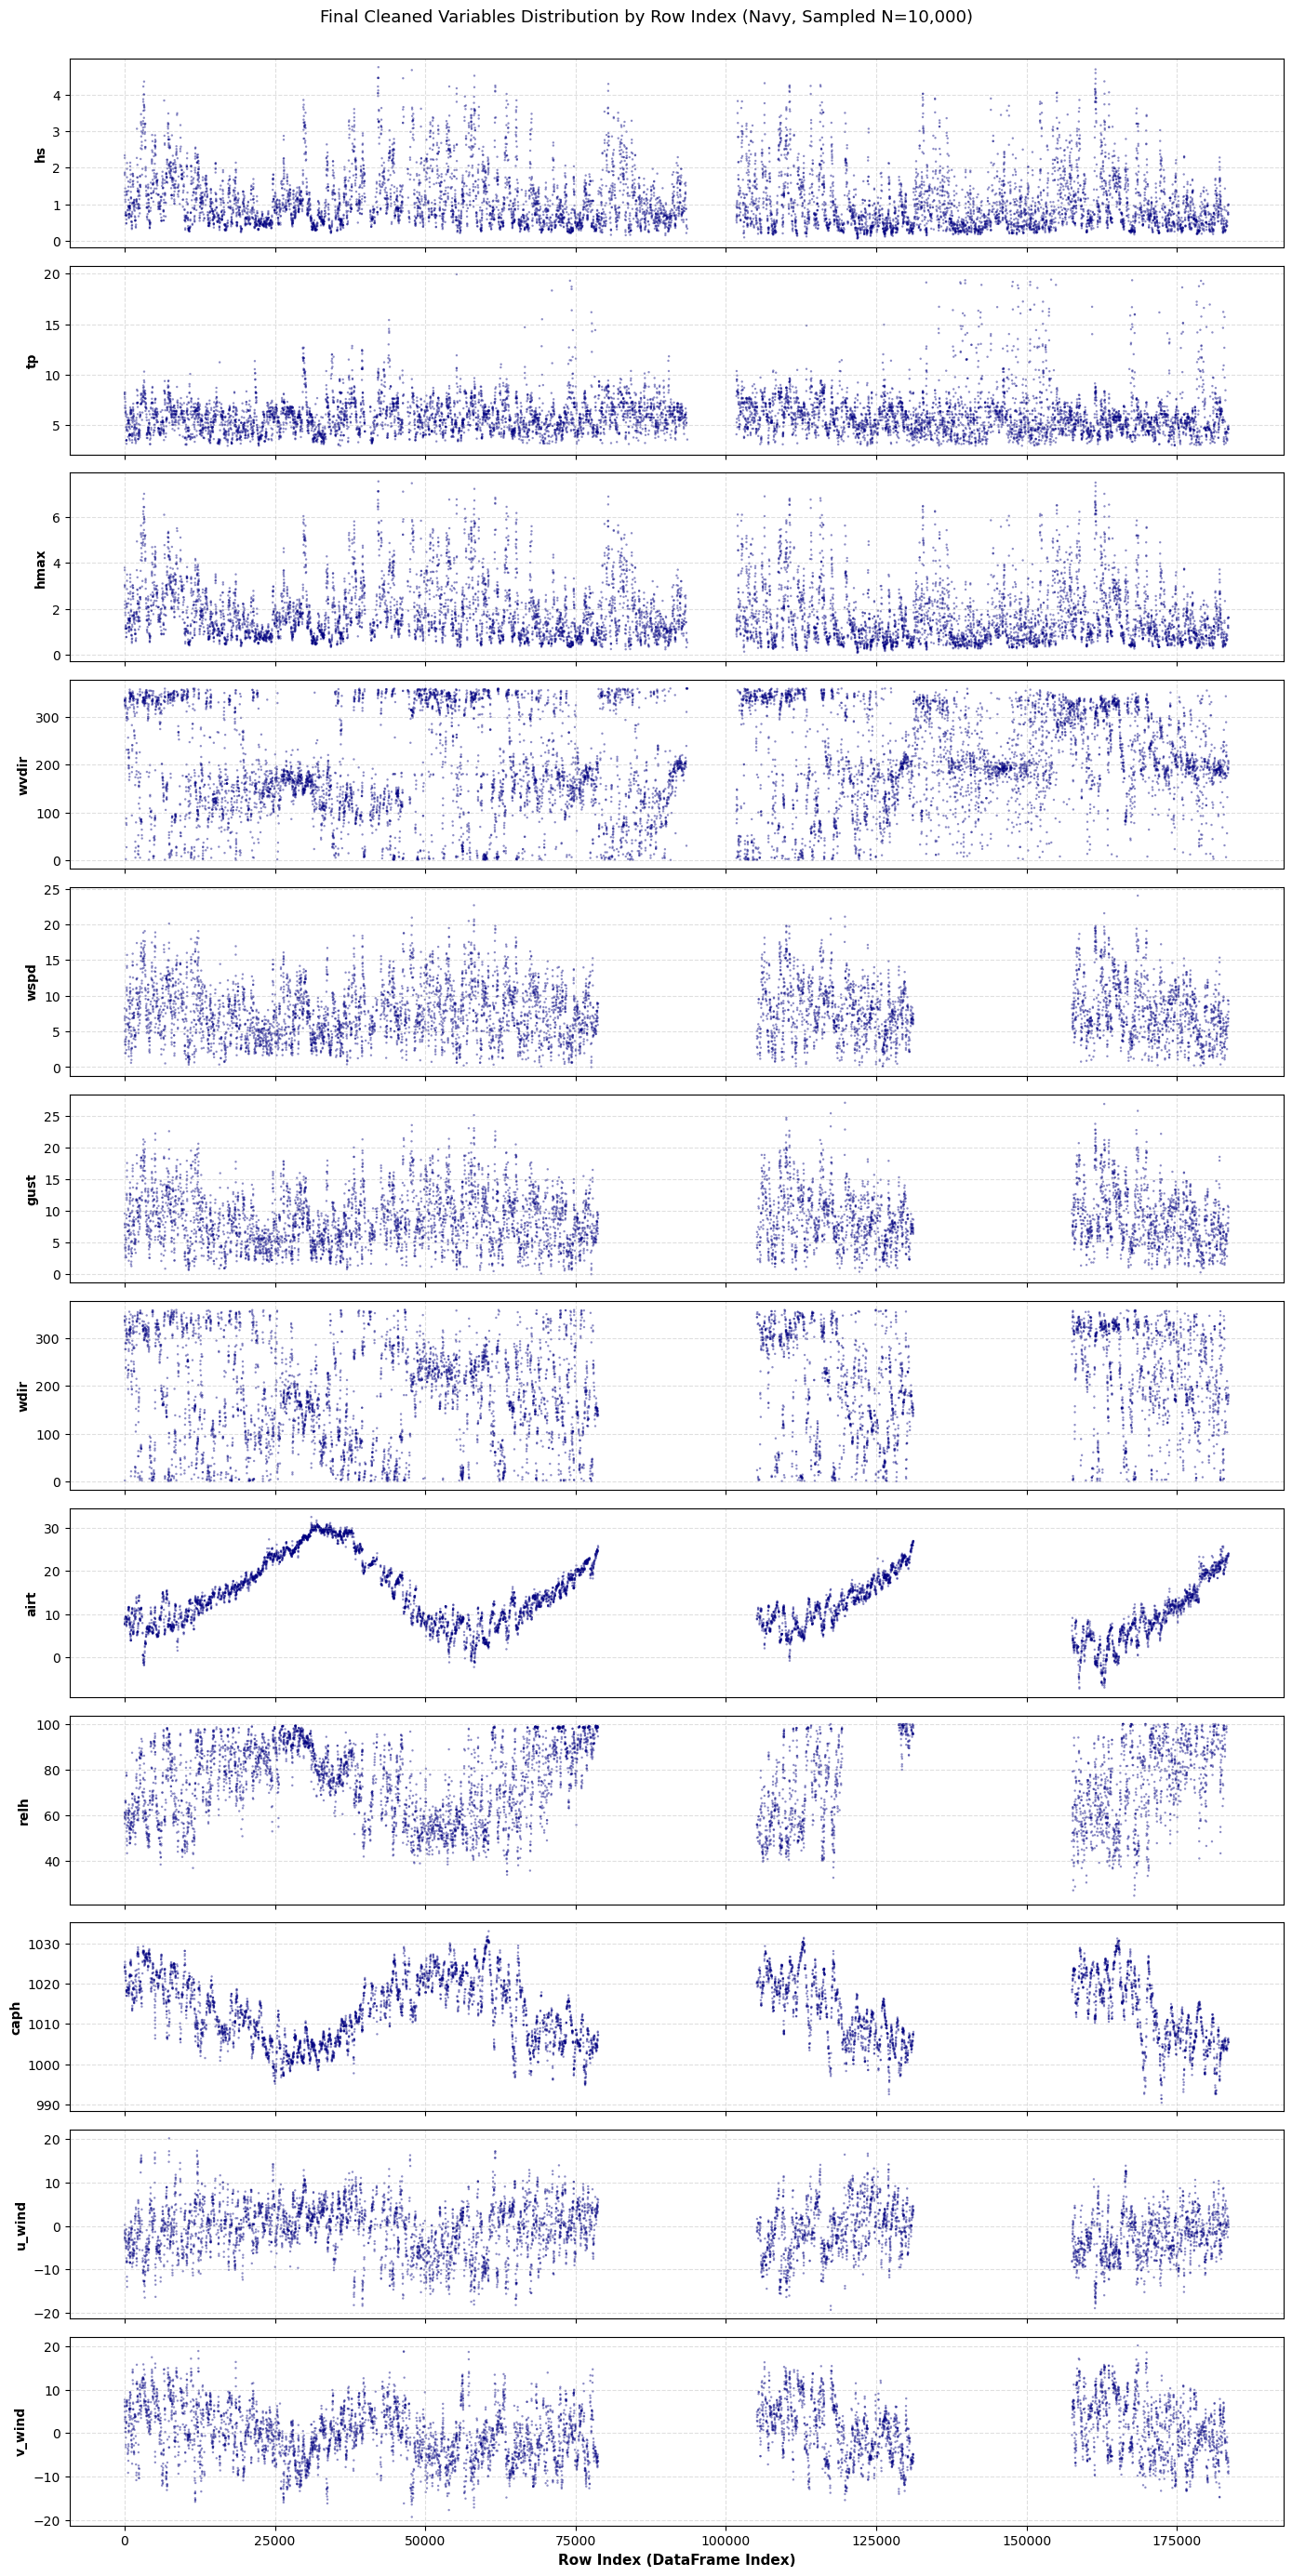

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. 데이터 로드 및 최종 물리 제약 클리핑
df = pd.read_csv("train_anomaly_cleaned.csv")
df["time"] = pd.to_datetime(df["time"])

# 물리적 모순 최종 보정
df["hmax"] = np.maximum(df["hmax"], df["hs"])
df["gust"] = np.maximum(df["gust"], df["wspd"])

# 바람 벡터 성분 계산
rad = np.deg2rad(df["wdir"])
df["u_wind"] = df["wspd"] * np.sin(rad)
df["v_wind"] = df["wspd"] * np.cos(rad)

# 2. 지정된 컬럼 순서로 정렬 후 train_final.csv로 저장
desired_order = [
    "case_id",
    "station",
    "step_minute",
    "time",
    "hs",
    "tp",
    "hmax",
    "wvdir",
    "wspd",
    "gust",
    "wdir",
    "airt",
    "relh",
    "caph",
    "u_wind",
    "v_wind",
]
existing_cols = [c for c in desired_order if c in df.columns]
remaining_cols = [c for c in df.columns if c not in existing_cols]
df_final = df[existing_cols + remaining_cols]

output_path = "train_final.csv"
df_final.to_csv(output_path, index=False)
print(f"최종 저장 완료: {output_path} (총 {len(df_final):,}개 행)")

# 3. 플롯 대상 수치형 컬럼 추출
exclude_cols = ["station", "time", "case_id"]
numeric_cols = [
    c
    for c in df_final.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(df_final[c])
]

# 4. 렌더링 최적화를 위한 인덱스 순서 유지 샘플링
sample_size = min(10000, len(df_final))
df_sample = df_final.sample(n=sample_size, random_state=42).sort_index()

# 5. 서브플롯 산점도 시각화 (남색 계열 적용)
n_cols = len(numeric_cols)
fig, axes = plt.subplots(
    nrows=n_cols, ncols=1, figsize=(14, 2.3 * n_cols), sharex=True
)

if n_cols == 1:
    axes = [axes]

navy_color = "#000080"  # 표준 남색 (Navy)

for ax, col in zip(axes, numeric_cols):
    ax.scatter(
        df_sample.index,
        df_sample[col],
        s=3,
        alpha=0.45,
        color=navy_color,
        edgecolors="none",
    )
    ax.set_ylabel(col, fontsize=10, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.4)

axes[-1].set_xlabel(
    "Row Index (DataFrame Index)", fontsize=11, fontweight="bold"
)
plt.suptitle(
    f"Final Cleaned Variables Distribution by Row Index (Navy, Sampled N={sample_size:,})",
    fontsize=13,
    y=1.002,
)
plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import pandas as pd

df = pd.read_csv("train_final.csv")
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(by=["station", "time"]).reset_index(drop=True)

# 1. 물리적 절대 제약
df.loc[df["hs"] <= 0.05, "hs"] = np.nan
df.loc[df["wspd"] < 0, "wspd"] = np.nan
df.loc[df["hmax"] < df["hs"], "hmax"] = np.nan
df.loc[df["gust"] < df["wspd"], "gust"] = np.nan
df.loc[(df["caph"] < 950) | (df["caph"] > 1050), "caph"] = np.nan

# 2. [핵심] 시계열 문맥 이상치 (10분 차분 급변 스파이크 & 저점 드롭아웃 탐지)
for station, grp in df.groupby("station"):
    idx = grp.index
    
    # (1) 10분 만에 1.0m 이상 급변하는 이상치 마스킹 (상승/하강 모두)
    diff = df.loc[idx, "hs"].diff().abs()
    df.loc[idx[diff > 1.0], "hs"] = np.nan
    
    # (2) 주변(앞뒤 30분) 평균 대비 비정상 급락(Dropouts) 마스킹
    rolling_med = df.loc[idx, "hs"].rolling(window=5, center=True, min_periods=1).median()
    is_dropout = (rolling_med > 1.5) & (df.loc[idx, "hs"] < 0.5)
    df.loc[idx[is_dropout], "hs"] = np.nan

# 3. 깨끗해진 상태에서 20분 주기 결측치만 단기 선형 보간
numeric_cols = ["hs", "tp", "hmax", "wvdir", "wspd", "gust", "wdir", "airt", "relh", "caph"]
df[numeric_cols] = df.groupby("station")[numeric_cols].transform(
    lambda g: g.interpolate(method="linear", limit=2)
)

# 4. 물리적 제약 최종 클리핑
df["hmax"] = np.maximum(df["hmax"], df["hs"])
df["gust"] = np.maximum(df["gust"], df["wspd"])

df.to_csv("train_final.csv", index=False)
print("급변 스파이크 및 저점 드롭아웃 마스킹 완료: train_final.csv 저장")

급변 스파이크 및 저점 드롭아웃 마스킹 완료: train_final.csv 저장


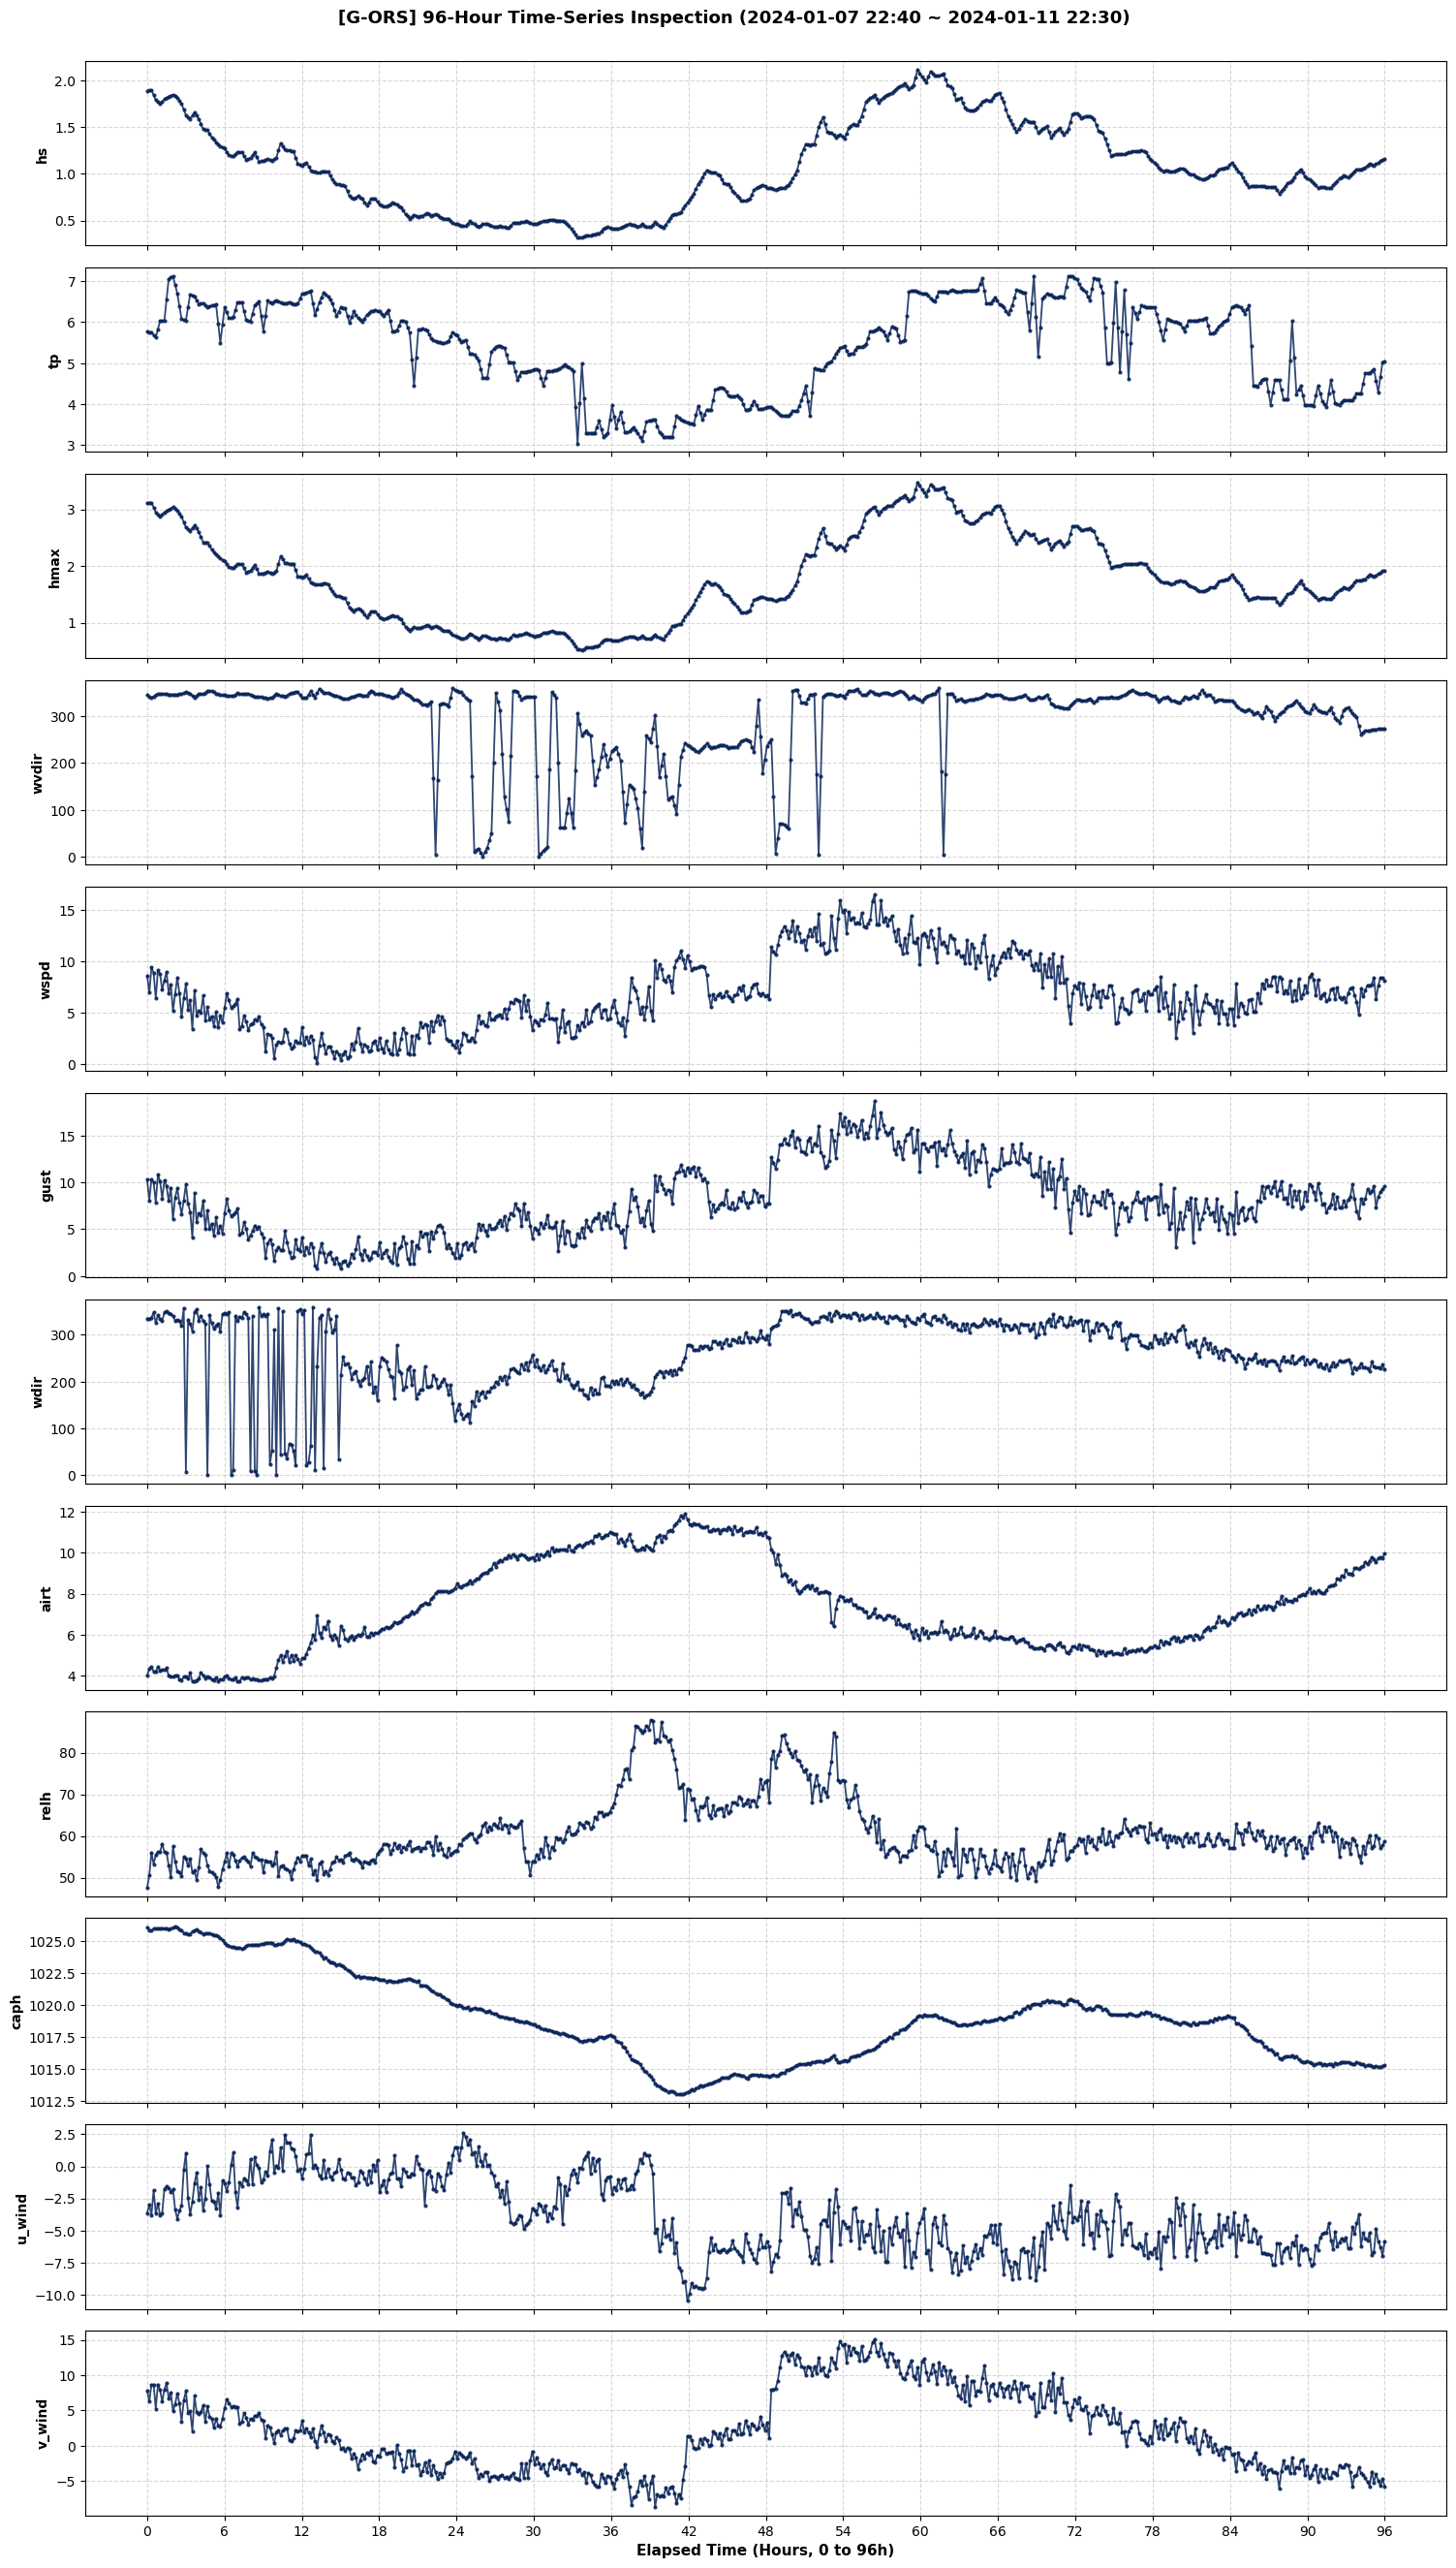

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. 정제 데이터 로드 및 정렬
df = pd.read_csv("train_final.csv")
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(by=["station", "time"]).reset_index(drop=True)

# 2. 첫 번째 기지(0번) 데이터 추출
first_station = df["station"].unique()[0]
df_station = (
    df[df["station"] == first_station].sort_values("time").reset_index(drop=True)
)

# 3. 96시간(576개 시점, 10분 단위) 연속 구간 추출 (결측이 적은 대표 구간 선택)
WINDOW_STEPS = 96 * 6  # 576스텝
start_idx = 1000  # 안정적인 관측 구간 시작 인덱스
end_idx = start_idx + WINDOW_STEPS
df_window = df_station.iloc[start_idx:end_idx].reset_index(drop=True)

# 4. 시각화 대상 수치형 컬럼 정의
exclude_cols = ["station", "time", "case_id", "step_minute"]
numeric_cols = [
    c
    for c in df_window.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(df_window[c])
]

# x축: 0시간부터 96시간까지의 경과 시간 (Hours)
time_hours = np.linspace(0, 96, len(df_window))

# 5. 서브플롯 시각화 (남색 계열 실선 및 마커)
n_cols = len(numeric_cols)
fig, axes = plt.subplots(
    nrows=n_cols, ncols=1, figsize=(15, 2.2 * n_cols), sharex=True
)

if n_cols == 1:
    axes = [axes]

navy_color = "#0B2559"

for ax, col in zip(axes, numeric_cols):
  ax.plot(
      time_hours,
      df_window[col],
      color=navy_color,
      linewidth=1.3,
      marker="o",
      markersize=2,
      alpha=0.85,
  )
  ax.set_ylabel(col, fontsize=10, fontweight="bold")
  ax.grid(True, linestyle="--", alpha=0.5)

axes[-1].set_xlabel("Elapsed Time (Hours, 0 to 96h)", fontsize=11, fontweight="bold")
xticks = np.arange(0, 97, 6)  # 6시간 간격 눈금
axes[-1].set_xticks(xticks)

start_str = df_window["time"].iloc[0].strftime("%Y-%m-%d %H:%M")
end_str = df_window["time"].iloc[-1].strftime("%Y-%m-%d %H:%M")
plt.suptitle(
    f"[{first_station}] 96-Hour Time-Series Inspection ({start_str} ~"
    f" {end_str})",
    fontsize=13,
    fontweight="bold",
    y=1.002,
)
plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression

# ============================================================
# 1. 원본 파일 읽기
# ============================================================
df = pd.read_csv("train.csv")

df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(["station", "time"]).reset_index(drop=True)

print("shape:", df.shape)
print(df.columns.tolist())


# ============================================================
# 2. 분석 대상 변수
# ============================================================
TARGET = "hs"

FEATURES = [
    "tp",
    "hmax",
    "wspd",
    "gust",
    "caph",
    "airt",
    "relh",
]

# 데이터가 10분 간격이므로
# 1h = 6 step
LAG_HOURS = [0, 1, 3, 6, 9, 12, 18, 24]
LAG_STEPS = {h: h * 6 for h in LAG_HOURS}


# ============================================================
# 3. Lag Correlation
# X(t-lag) vs hs(t)
# ============================================================
corr_results = []

for station, g in df.groupby("station"):
    g = g.sort_values("time").reset_index(drop=True)

    for feature in FEATURES:
        for lag_h, lag_step in LAG_STEPS.items():

            x = g[feature].shift(lag_step)
            y = g[TARGET]

            valid = x.notna() & y.notna()

            if valid.sum() < 100:
                continue

            corr = x[valid].corr(y[valid])

            corr_results.append({
                "station": station,
                "feature": feature,
                "lag_hour": lag_h,
                "corr": corr,
                "abs_corr": abs(corr),
                "n": valid.sum(),
            })

corr_df = pd.DataFrame(corr_results)

print("\n=== Station별 Lag Correlation ===")
print(corr_df.head())


# ============================================================
# 4. Station 평균 Lag Correlation
# ============================================================
corr_summary = (
    corr_df
    .groupby(["feature", "lag_hour"], as_index=False)
    .agg(
        mean_corr=("corr", "mean"),
        mean_abs_corr=("abs_corr", "mean"),
        station_count=("station", "nunique"),
    )
)

print("\n=== 전체 Station 평균 Lag Correlation ===")
print(
    corr_summary
    .sort_values(["feature", "mean_abs_corr"], ascending=[True, False])
)


# ============================================================
# 5. 변수별 Best Lag
# ============================================================
best_corr = (
    corr_summary
    .sort_values("mean_abs_corr", ascending=False)
    .groupby("feature")
    .head(1)
    .sort_values("mean_abs_corr", ascending=False)
    .reset_index(drop=True)
)

print("\n=== Feature별 Best Lag Correlation ===")
print(best_corr)


# ============================================================
# 6. Lagged Mutual Information
# 비선형 관계 확인
# ============================================================
mi_results = []

# MI 계산량이 크므로 station별 최대 샘플 제한
MAX_MI_SAMPLES = 30000

for station, g in df.groupby("station"):
    g = g.sort_values("time").reset_index(drop=True)

    for feature in FEATURES:
        for lag_h, lag_step in LAG_STEPS.items():

            x = g[feature].shift(lag_step)
            y = g[TARGET]

            tmp = pd.DataFrame({
                "x": x,
                "y": y,
            }).dropna()

            if len(tmp) < 100:
                continue

            if len(tmp) > MAX_MI_SAMPLES:
                tmp = tmp.sample(
                    MAX_MI_SAMPLES,
                    random_state=42
                )

            mi = mutual_info_regression(
                tmp[["x"]],
                tmp["y"],
                random_state=42
            )[0]

            mi_results.append({
                "station": station,
                "feature": feature,
                "lag_hour": lag_h,
                "mi": mi,
                "n": len(tmp),
            })

mi_df = pd.DataFrame(mi_results)

print("\n=== Station별 Lagged MI ===")
print(mi_df.head())


# ============================================================
# 7. Station 평균 MI
# ============================================================
mi_summary = (
    mi_df
    .groupby(["feature", "lag_hour"], as_index=False)
    .agg(
        mean_mi=("mi", "mean"),
        station_count=("station", "nunique"),
    )
)

print("\n=== 전체 Station 평균 Lagged MI ===")
print(
    mi_summary
    .sort_values(["feature", "mean_mi"], ascending=[True, False])
)


# ============================================================
# 8. 변수별 Best MI Lag
# ============================================================
best_mi = (
    mi_summary
    .sort_values("mean_mi", ascending=False)
    .groupby("feature")
    .head(1)
    .sort_values("mean_mi", ascending=False)
    .reset_index(drop=True)
)

print("\n=== Feature별 Best Lagged MI ===")
print(best_mi)


# ============================================================
# 9. Lag Corr + MI 결과 합치기
# ============================================================
comparison = pd.merge(
    best_corr[
        ["feature", "lag_hour", "mean_corr", "mean_abs_corr"]
    ].rename(columns={
        "lag_hour": "best_corr_lag_h"
    }),
    best_mi[
        ["feature", "lag_hour", "mean_mi"]
    ].rename(columns={
        "lag_hour": "best_mi_lag_h"
    }),
    on="feature",
    how="outer",
)

print("\n=== 최종 비교 ===")
print(comparison)


# ============================================================
# 10. CSV 저장
# ============================================================
corr_df.to_csv("lag_corr_by_station.csv", index=False)
corr_summary.to_csv("lag_corr_summary.csv", index=False)

mi_df.to_csv("lag_mi_by_station.csv", index=False)
mi_summary.to_csv("lag_mi_summary.csv", index=False)

comparison.to_csv("lag_corr_mi_comparison.csv", index=False)

print("\n저장 완료")

shape: (183600, 12)
['station', 'time', 'hs', 'tp', 'hmax', 'wvdir', 'wspd', 'gust', 'wdir', 'airt', 'relh', 'caph']

=== Station별 Lag Correlation ===
  station feature  lag_hour      corr  abs_corr      n
0   G-ORS      tp         0  0.483411  0.483411  37522
1   G-ORS      tp         1  0.466376  0.466376  37383
2   G-ORS      tp         3  0.436708  0.436708  37284
3   G-ORS      tp         6  0.391689  0.391689  37228
4   G-ORS      tp         9  0.360471  0.360471  37156

=== 전체 Station 평균 Lag Correlation ===
   feature  lag_hour  mean_corr  mean_abs_corr  station_count
0     airt         0  -0.422950       0.422950              3
1     airt         1  -0.420130       0.420130              3
2     airt         3  -0.412472       0.412472              3
3     airt         6  -0.397385       0.397385              3
4     airt         9  -0.380072       0.380072              3
5     airt        12  -0.362887       0.362887              3
6     airt        18  -0.331277       0.331277

In [2]:
import numpy as np
import pandas as pd

# ============================================================
# 1. 원본 데이터 로드
# ============================================================
atmos = pd.read_csv("train_atmos.csv")
wave = pd.read_csv("train_wave.csv")

atmos["time"] = pd.to_datetime(atmos["time"])
wave["time"] = pd.to_datetime(wave["time"])

df = pd.merge(
    wave,
    atmos,
    on=["station", "time"],
    how="outer"
)

df = df.sort_values(["station", "time"]).reset_index(drop=True)

print("shape:", df.shape)
print(df.columns.tolist())


# ============================================================
# 2. 물리 기반 파생변수 생성
# ============================================================
def make_physics_features(g):
    g = g.sort_values("time").copy()

    # --------------------------------------------------------
    # (1) Wind-Wave Alignment
    # 풍향과 파향이 얼마나 같은 방향인지
    #  1 : 같은 방향
    #  0 : 직각
    # -1 : 반대 방향
    # --------------------------------------------------------
    angle_diff = np.deg2rad(g["wdir"] - g["wvdir"])

    g["wind_wave_alignment"] = np.cos(angle_diff)

    # 방향 차이 자체 (0~180도)
    g["wind_wave_diff"] = np.abs(
        (g["wdir"] - g["wvdir"] + 180) % 360 - 180
    )

    # --------------------------------------------------------
    # (2) Gust 관련
    # 평균풍속 대비 돌풍 강도
    # --------------------------------------------------------
    g["gust_minus_wspd"] = g["gust"] - g["wspd"]

    g["gust_ratio"] = (
        g["gust"] / g["wspd"].replace(0, np.nan)
    )

    # --------------------------------------------------------
    # (3) 기압 변화량
    # 데이터 10분 간격
    # 3h = 18 step
    # 6h = 36 step
    # 12h = 72 step
    # --------------------------------------------------------
    g["caph_change_3h"] = g["caph"] - g["caph"].shift(18)
    g["caph_change_6h"] = g["caph"] - g["caph"].shift(36)
    g["caph_change_12h"] = g["caph"] - g["caph"].shift(72)

    # --------------------------------------------------------
    # (4) 풍속 최근 지속 효과
    # 최근 몇 시간 평균 풍속
    # --------------------------------------------------------
    g["wspd_mean_3h"] = g["wspd"].rolling(
        18, min_periods=6
    ).mean()

    g["wspd_mean_6h"] = g["wspd"].rolling(
        36, min_periods=12
    ).mean()

    g["wspd_mean_12h"] = g["wspd"].rolling(
        72, min_periods=24
    ).mean()

    # --------------------------------------------------------
    # (5) 최근 최대 돌풍
    # --------------------------------------------------------
    g["gust_max_3h"] = g["gust"].rolling(
        18, min_periods=6
    ).max()

    g["gust_max_6h"] = g["gust"].rolling(
        36, min_periods=12
    ).max()

    g["gust_max_12h"] = g["gust"].rolling(
        72, min_periods=24
    ).max()

    # --------------------------------------------------------
    # (6) 풍속 변화량
    # --------------------------------------------------------
    g["wspd_change_3h"] = g["wspd"] - g["wspd"].shift(18)
    g["wspd_change_6h"] = g["wspd"] - g["wspd"].shift(36)

    # --------------------------------------------------------
    # (7) 기온 / 습도 변화
    # --------------------------------------------------------
    g["airt_change_6h"] = g["airt"] - g["airt"].shift(36)
    g["relh_change_6h"] = g["relh"] - g["relh"].shift(36)

    return g


df_phy = (
    df.groupby("station", group_keys=False)
      .apply(make_physics_features)
      .reset_index(drop=True)
)


# ============================================================
# 3. 새 파생변수와 hs의 correlation 확인
# ============================================================
NEW_FEATURES = [
    "wind_wave_alignment",
    "wind_wave_diff",

    "gust_minus_wspd",
    "gust_ratio",

    "caph_change_3h",
    "caph_change_6h",
    "caph_change_12h",

    "wspd_mean_3h",
    "wspd_mean_6h",
    "wspd_mean_12h",

    "gust_max_3h",
    "gust_max_6h",
    "gust_max_12h",

    "wspd_change_3h",
    "wspd_change_6h",

    "airt_change_6h",
    "relh_change_6h",
]


results = []

for station, g in df_phy.groupby("station"):

    for feature in NEW_FEATURES:

        tmp = g[["hs", feature]].dropna()

        if len(tmp) < 100:
            continue

        corr = tmp["hs"].corr(tmp[feature])

        results.append({
            "station": station,
            "feature": feature,
            "corr": corr,
            "abs_corr": abs(corr),
            "n": len(tmp)
        })


corr_station = pd.DataFrame(results)

corr_summary = (
    corr_station
    .groupby("feature", as_index=False)
    .agg(
        mean_corr=("corr", "mean"),
        mean_abs_corr=("abs_corr", "mean"),
        station_count=("station", "nunique")
    )
    .sort_values(
        "mean_abs_corr",
        ascending=False
    )
)

print("\n=== Physics Feature vs Hs ===")
print(corr_summary.to_string(index=False))


# ============================================================
# 4. 기존 변수와 같이 비교
# ============================================================
BASE_FEATURES = [
    "tp",
    "hmax",
    "wspd",
    "gust",
    "caph",
    "airt",
    "relh"
]

ALL_FEATURES = BASE_FEATURES + NEW_FEATURES

all_results = []

for station, g in df_phy.groupby("station"):

    for feature in ALL_FEATURES:

        tmp = g[["hs", feature]].dropna()

        if len(tmp) < 100:
            continue

        corr = tmp["hs"].corr(tmp[feature])

        all_results.append({
            "station": station,
            "feature": feature,
            "corr": corr,
            "abs_corr": abs(corr)
        })


all_corr = pd.DataFrame(all_results)

all_summary = (
    all_corr
    .groupby("feature", as_index=False)
    .agg(
        mean_corr=("corr", "mean"),
        mean_abs_corr=("abs_corr", "mean")
    )
    .sort_values(
        "mean_abs_corr",
        ascending=False
    )
)

print("\n=== Base + Physics Feature Ranking ===")
print(all_summary.to_string(index=False))


# ============================================================
# 5. station별 결과 확인
# ============================================================
print("\n=== Station별 Physics Feature Ranking ===")

for station in corr_station["station"].unique():

    print(f"\n[{station}]")

    temp = (
        corr_station[
            corr_station["station"] == station
        ]
        .sort_values(
            "abs_corr",
            ascending=False
        )
    )

    print(
        temp[
            ["feature", "corr", "abs_corr"]
        ].to_string(index=False)
    )


# ============================================================
# 6. 저장
# ============================================================
corr_station.to_csv(
    "physics_feature_corr_by_station.csv",
    index=False
)

corr_summary.to_csv(
    "physics_feature_corr_summary.csv",
    index=False
)

all_summary.to_csv(
    "all_feature_corr_summary.csv",
    index=False
)

print("\n저장 완료")

shape: (183600, 12)
['station', 'time', 'hs', 'tp', 'hmax', 'wvdir', 'wspd', 'gust', 'wdir', 'airt', 'relh', 'caph']


C:\Users\user\AppData\Local\Temp\ipykernel_27740\271526979.py:117: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(make_physics_features)



=== Physics Feature vs Hs ===
            feature  mean_corr  mean_abs_corr  station_count
       gust_max_12h   0.821552       0.821552              3
      wspd_mean_12h   0.813157       0.813157              3
        gust_max_6h   0.806723       0.806723              3
       wspd_mean_6h   0.788776       0.788776              3
        gust_max_3h   0.779739       0.779739              3
       wspd_mean_3h   0.753728       0.753728              3
    gust_minus_wspd   0.513589       0.513589              3
     wind_wave_diff  -0.296360       0.296360              3
wind_wave_alignment   0.280931       0.280931              3
    caph_change_12h   0.246824       0.246824              3
     caph_change_6h   0.219231       0.219231              3
     caph_change_3h   0.187859       0.187859              3
     airt_change_6h  -0.152678       0.152678              3
     relh_change_6h  -0.123694       0.123694              3
     wspd_change_3h  -0.112146       0.112146         

In [3]:
import numpy as np
import pandas as pd

# ============================================================
# 1. 전처리 완료 데이터 로드
# ============================================================
df = pd.read_csv("train_final.csv")

df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(["station", "time"]).reset_index(drop=True)


# ============================================================
# 2. 물리 기반 Feature 추가
# ============================================================
def add_physics_features(g):
    g = g.sort_values("time").copy()

    # --------------------------------------------------------
    # 1) 최근 바람 지속 효과
    # --------------------------------------------------------
    g["wspd_mean_6h"] = (
        g["wspd"]
        .rolling(36, min_periods=12)
        .mean()
    )

    g["wspd_mean_12h"] = (
        g["wspd"]
        .rolling(72, min_periods=24)
        .mean()
    )

    # --------------------------------------------------------
    # 2) 최근 최대 돌풍
    # --------------------------------------------------------
    g["gust_max_6h"] = (
        g["gust"]
        .rolling(36, min_periods=12)
        .max()
    )

    g["gust_max_12h"] = (
        g["gust"]
        .rolling(72, min_periods=24)
        .max()
    )

    # --------------------------------------------------------
    # 3) 평균풍속 대비 돌풍 초과량
    # --------------------------------------------------------
    g["gust_minus_wspd"] = g["gust"] - g["wspd"]

    # --------------------------------------------------------
    # 4) 풍향 - 파향 관계
    # --------------------------------------------------------
    angle_diff = np.deg2rad(
        g["wdir"] - g["wvdir"]
    )

    g["wind_wave_alignment"] = np.cos(angle_diff)

    g["wind_wave_diff"] = np.abs(
        (g["wdir"] - g["wvdir"] + 180) % 360 - 180
    )

    # --------------------------------------------------------
    # 5) 기압 변화
    # --------------------------------------------------------
    g["caph_change_6h"] = (
        g["caph"] - g["caph"].shift(36)
    )

    g["caph_change_12h"] = (
        g["caph"] - g["caph"].shift(72)
    )

    return g


dfs = []

for station, g in df.groupby("station"):
    dfs.append(add_physics_features(g))

df = pd.concat(dfs, ignore_index=True)

df = df.sort_values(
    ["station", "time"]
).reset_index(drop=True)


# ============================================================
# 3. u/v wind 최종 재계산
# ============================================================

rad = np.deg2rad(df["wdir"])

df["u_wind"] = df["wspd"] * np.sin(rad)
df["v_wind"] = df["wspd"] * np.cos(rad)


# ============================================================
# 4. 확인
# ============================================================
NEW_FEATURES = [
    "wspd_mean_6h",
    "wspd_mean_12h",
    "gust_max_6h",
    "gust_max_12h",
    "gust_minus_wspd",
    "wind_wave_alignment",
    "wind_wave_diff",
    "caph_change_6h",
    "caph_change_12h",
]

print(df[NEW_FEATURES].describe().T)

print("\nMissing ratio")
print(
    df[NEW_FEATURES]
    .isna()
    .mean()
    .sort_values(ascending=False)
)


# ============================================================
# 5. 저장
# ============================================================
df.to_csv(
    "train_final_physics.csv",
    index=False
)

print("\nSaved: train_final_physics.csv")
print("shape:", df.shape)

                        count       mean        std        min        25%  \
wspd_mean_6h         128642.0   7.764280   3.661699   0.122835   4.942785   
wspd_mean_12h        128712.0   7.763998   3.505146   0.552598   5.057014   
gust_max_6h          128642.0  11.052090   4.684667   0.380333   7.448000   
gust_max_12h         128712.0  12.044028   4.747634   1.764000   8.430000   
gust_minus_wspd      128478.0   0.862644   0.686024   0.000000   0.393000   
wind_wave_alignment  127730.0   0.353895   0.664710  -1.000000  -0.182750   
wind_wave_diff       127730.0  63.147325  49.894644   0.000000  19.556250   
caph_change_6h       128239.0  -0.012067   1.776423  -9.627000  -1.129000   
caph_change_12h      127780.0  -0.022037   2.623391 -14.993000  -1.538000   

                           50%         75%         max  
wspd_mean_6h          7.392444   10.215486   20.963611  
wspd_mean_12h         7.402347   10.092500   19.541875  
gust_max_6h          10.490000   14.010000   32.630000  
g